# Lecture 3 (Part 1 of 2) — Flux, Injection & Weighting with **SIREN**

### Neutrino Interactions, Simulation and Event Generation · *N. Kamp*

Lectures 1 & 2 built the physics: how neutrinos **interact** (cross sections, DIS kinematics,
the "Grand Unified Neutrino Spectrum") and how the charged particles they make **propagate and
radiate**. This third lecture is the hands-on **simulation pipeline** that strings those ideas
together:

```
   FLUX            ->   INTERACTION        ->   PROPAGATION + LIGHT + DETECTOR
   what hits us         where/how it scatters   what we actually see
   [        this notebook: SIREN         ]      [ notebook 2: PROPOSAL + Prometheus ]
```

**This is the first of two notebooks.** Here we use **SIREN** (the modern successor to
LeptonInjector) to do the first two stages *fully live*:

1. **Flux** — load the atmospheric flux from SIREN's tables and write down the astrophysical one.
2. **Interaction** — inject high-energy $\nu_\mu$ charged-current events into IceCube.
3. **Weights** — turn that one generated sample into a physical **event rate** for *any* flux.

Everything runs live in Colab from public data — no pre-built cache files. Notebook 2 picks up
the charged lepton (PROPOSAL) and the light it makes in the ice (Prometheus).


## Setup

SIREN is a compiled C++/Python package for simulating different types of neutrino interactions in different detector environments, under different flux assumptions. Designed for maximium flexibility.

**Check it out yourself!**
 - 📄 **Paper:** SIREN, [Schneider, NK, Wen arXiv:2406.01745](https://arxiv.org/abs/2406.01745)
 - 💻 **Code:** [github.com/Harvard-Neutrino/SIREN](https://github.com/Harvard-Neutrino/SIREN)
 - **"pip install siren"** [pypi.org/project/siren](https://pypi.org/project/siren/#description)


In [1]:
# install relevant packages
import sys, os, subprocess
def pip(*args):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *args], check=True)

# SIREN currently pins numpy<2, but Colab's prebuilt awkward/pyarrow are numpy-2.x builds,
# so we put numpy back to 2.x after installing SIREN. The reinstall is done ONCE (guarded
# by a sentinel file) so re-running this cell is a no-op.
_DONE = "/tmp/.siren_env_ready"
if "google.colab" in sys.modules and not os.path.exists(_DONE):
    pip("siren")
    pip("--force-reinstall", "numpy>=2")
    open(_DONE, "w").close()

# Import the compiled stack. If a stale numpy is still held in this process (so the ABI
# doesn't match the freshly installed one), restart the kernel ONCE automatically and the
# cell will import cleanly on the re-run. A second sentinel prevents a restart loop.
_RESTARTED = "/tmp/.siren_env_restarted"
try:
    import numpy as np, siren, awkward as ak, matplotlib.pyplot as plt
except (ValueError, ImportError) as e:
    if os.path.exists(_RESTARTED):
        raise                                  # already restarted once -- surface the error
    open(_RESTARTED, "w").close()
    print("Applying the numpy update -- restarting the kernel once automatically.")
    print("On Colab the kernel will come back on its own; just re-run the cells.")
    os.kill(os.getpid(), 9)

print("numpy", np.__version__, "| siren", getattr(siren, "__version__", "?"))


numpy 2.5.0 | siren 0.1.0


### The bundled download scripts

SIREN's detectors, cross-section splines, and flux tables are **data files** hosted on Zenodo
(record `20129082`) and a companion GitHub data repo. They are *not* shipped inside the wheel —
SIREN downloads them on demand the first time a loader needs them. SIREN exposes a small CLI,
**`siren-download`**, to inspect and pre-fetch that data. Let's use it explicitly.

First, list everything SIREN knows how to load:


Now **pre-fetch** exactly what this notebook needs — the CSMS deep-inelastic cross-section
splines and the atmospheric flux tables. (If you skip this, the loaders below would download the
same files automatically the first time they run; doing it up front just makes the data step
explicit.)

> **Why this stays small.** The cross-section archive on Zenodo bundles *many* process models.
> SIREN's `ensure_zenodo_archive(...)` helper does **prefix extraction**: it pulls the one zip
> from Zenodo but only unpacks the entries under the prefix you asked for (e.g. just
> `CSMSDISSplines`), so you don't pay disk/time for the dipole-portal, HNL, MARLEY, … tables you
> aren't using.


In [2]:
# Pre-fetch the two resources we use. Each prints a download/extract progress line.
subprocess.run(["siren-download", "--fetch", "CSMSDISSplines"], check=True)
subprocess.run(["siren-download", "--fetch", "Atmospheric"], check=True)
print("\nData ready.")



Data ready.


## 1. The flux — what's hitting the detector?

A neutrino telescope's "menu" is dominated by two diffuse fluxes (see **Lecture 1: the Grand
Unified Neutrino Spectrum** — the eV-to-EeV census of every neutrino source):

1. **Atmospheric** $\nu$ from cosmic-ray air showers — steeply falling ($\sim E^{-3.7}$ at high
   energy), the dominant background below $\sim$100 TeV.
2. **Astrophysical** $\nu$ — a near-isotropic diffuse flux from distant accelerators, well
   described by a single **power law** $\propto E^{-\gamma}$.

The flux is the first factor in the master formula every counting experiment uses (**Lecture 1**):

$$ \text{Rate} \;=\; \underbrace{\Phi(E,\theta)}_{\text{flux}} \;\times\; \underbrace{\sigma(E)}_{\text{cross section}} \;\times\; \underbrace{N_{\text{targets}}}_{\text{detector}} \;\times\; \underbrace{\varepsilon}_{\text{efficiency}} $$

SIREN ships the **atmospheric** flux as tabulated tables (several hadronic models, both at the
**surface** and **at the detector** after Earth propagation). The astrophysical flux is so simple
we just write it analytically.


In [ ]:
# --- Atmospheric flux from SIREN's tables ------------------------------------
# load_flux returns a PATH to a text table with columns: [E_GeV, cos(zenith), flux].
# Tag format:  {model}_{osc|unosc}_{species1}_{species2}_...
#   model in {bartol, daemonflux, H3a_SIBYLL21, H3a_SIBYLL23C, honda2006}
#   unosc = at the surface,  osc = at the detector (nuSQuIDS oscillation + Earth interactions/absorption folded in)
MODEL = "daemonflux"

def load_atmo_table(tag):
    path = siren.utilities.load_flux("Atmospheric", tag=tag)
    d = np.loadtxt(path)                      # columns: E, cos_zenith, flux
    E   = np.unique(d[:, 0])
    cz  = np.unique(d[:, 1])
    # The table is written energy-major (energy fixed, cos_zenith sweeps -1 -> +1),
    # so reshape (n_E, n_cz) directly gives [energy, cos_zenith] -- no transpose.
    flux = d[:, 2].reshape(len(E), len(cz))
    return E, cz, flux

# numu + numubar, surface vs at-detector
E, cz, flux_surf_mu = load_atmo_table(f"{MODEL}_unosc_numu_numubar")
_, _, flux_det_mu   = load_atmo_table(f"{MODEL}_osc_numu_numubar")
_, _, flux_surf_e = load_atmo_table(f"{MODEL}_unosc_nue_nuebar")
_, _, flux_det_e   = load_atmo_table(f"{MODEL}_osc_nue_nuebar")
print(f"atmospheric table: {len(E)} energies x {len(cz)} zenith angles")
print(f"E range {E.min():.2g}-{E.max():.2g} GeV,  cos(zenith) {cz.min()}..{cz.max()}")


### 1a. The two fluxes a telescope sees

Average the atmospheric table over the sky (it's nearly isotropic at the high energies we care
about) and overlay the analytic astrophysical power law. Plotting $E^2\,d\Phi/dE$ flattens the
steep spectra so the **crossover** — where astrophysical overtakes atmospheric — is easy to read.

> **A note on normalization.** SIREN's tabulated atmospheric flux and our hand-written astrophysical
> power law are carried in *different unit conventions*, so a raw overlay isn't apples-to-apples.
> SIREN uses internal flux units of [GeV$^{-1}$ cm$^{-2}$s$^{-1}$sr$^{-1}$] while the astrophyisical single power law is reported in [GeV$^{-1}$ m$^{-2}$s$^{-1}$sr$^{-1}$]. Hence the scale factor of $10^{-4}$ below.


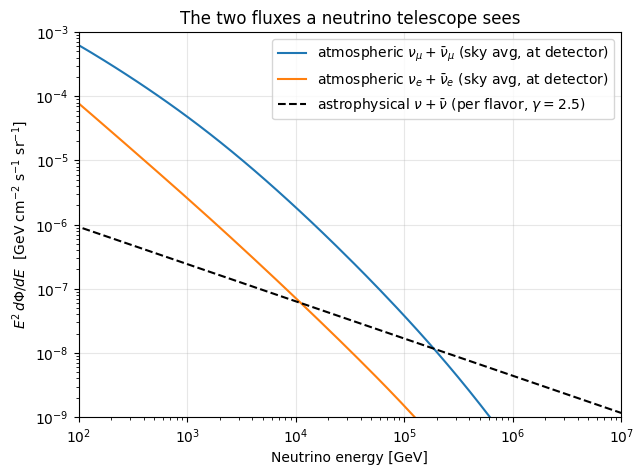

astrophysical overtakes atmospheric nu_mu (nu_e) near 186 (11) TeV (the energy above which a telescope's signal is mostly astrophysical)


In [4]:
def astro_powerlaw(E_gev, phi0=1.68e-18, gamma=2.58, E0=1e5):
    '''IceCube-style single power-law astrophysical flux (per flavor, nu+nubar),
    units GeV^-1 cm^-2 s^-1 sr^-1.  Defaults ~ IceCube diffuse fit.'''
    power_law = siren.distributions.PowerLaw(gamma,10,1e6)
    power_law.SetNormalizationAtEnergy(phi0,E0)
    return np.array([power_law.normalization*power_law.pdf(_E) for _E in E_gev])


# Rescale the atmospheric flux from per m^2 to per cm^2 and average over zenith
scale = 1e-4
phi_atmo_mu = flux_det_mu.mean(axis=1) * scale
phi_atmo_e = flux_det_e.mean(axis=1) * scale
# phi_atmo_tau = flux_det_tau.mean(axis=1) * scale # tau exists at lower energies

phi_astro = astro_powerlaw(E)

plt.figure(figsize=(7, 5))
plt.loglog(E, E**2 * phi_atmo_mu,  label=r"atmospheric $\nu_\mu+\bar\nu_\mu$ (sky avg, at detector)")
plt.loglog(E, E**2 * phi_atmo_e,  label=r"atmospheric $\nu_e+\bar\nu_e$ (sky avg, at detector)")
# plt.loglog(E, E**2 * phi_atmo_tau,  label=r"atmospheric $\nu_\tau+\bar\nu_\tau$ (sky avg, at detector)")
plt.loglog(E, E**2 * phi_astro, label=r"astrophysical $\nu+\bar\nu$ (per flavor, $\gamma=2.5$)",color="black",ls="--")
plt.xlabel("Neutrino energy [GeV]")
plt.ylabel(r"$E^2\,d\Phi/dE$  [GeV cm$^{-2}$ s$^{-1}$ sr$^{-1}$]")
plt.xlim(1e2, 1e7); plt.ylim(1e-9, 1e-3)
plt.legend(); plt.grid(alpha=0.3)
plt.title("The two fluxes a neutrino telescope sees")
plt.show()

# Where does astro overtake atmospheric?  Find the sign change of (astro - atmo) above 1 TeV.
hi = E > 1e3
diff = phi_astro[hi] - phi_atmo_mu[hi]
sign_change = np.where(np.diff(np.sign(diff)) > 0)[0]
cross_mu = E[hi][sign_change[0]] if len(sign_change) else np.nan
diff = phi_astro[hi] - phi_atmo_e[hi]
sign_change = np.where(np.diff(np.sign(diff)) > 0)[0]
cross_e = E[hi][sign_change[0]] if len(sign_change) else np.nan
print(f"astrophysical overtakes atmospheric nu_mu (nu_e) near {cross_mu/1e3:.0f} ({cross_e/1e3:.0f}) TeV "
      "(the energy above which a telescope's signal is mostly astrophysical)")


> **★ Discussion.** Change `gamma` from `2.5` to `2.0` (a *harder* astrophysical spectrum) and
> re-run. Which way does the crossover move, and why does a harder spectrum make high-energy events
> relatively more common? (This is exactly the lever that sets the energy threshold of a diffuse
> astrophysical search.)


### 1b. What the Earth does: surface vs at-detector

SIREN ships **both** the surface flux (`unosc`) and the at-detector flux (`osc`, already propagated
through the Earth with nuSQuIDS). Taking the **ratio** of the two reveals two physical effects at a
glance — without us running any oscillation/absorption code ourselves. We do this for $\nu_\mu$:

- **Oscillations** (tens of GeV): atmospheric $\nu_\mu \to \nu_\tau$ **disappearance** — up-going
  $\nu_\mu$ have the baseline (Earth's diameter) to oscillate away, so the detector/surface ratio
  dips **below 1** at low energy.
- **Earth absorption** (above $\sim$100 TeV): up-going neutrinos traverse a lot of rock and start to
  be absorbed by CC interactions and down-scattered by NC interactions. Ratio $< 1$ for up-going
  high energies, $> 1$ for intermediate energies.


In [ ]:
# nu_mu + nu_mubar, surface vs at-detector, across the (E, cos-zenith) plane
ratio = np.divide(flux_det_mu, flux_surf_mu, out=np.full_like(flux_det_mu, np.nan), where=flux_surf_mu > 0)

plt.figure(figsize=(7.5, 5))
pc = plt.pcolormesh(cz, E, ratio, shading="auto", vmin=0, vmax=2, cmap="RdBu_r")
plt.yscale("log"); plt.ylim(1, 1e7)
plt.ylabel("Neutrino energy [GeV]")
plt.xlabel(r"$\cos\theta_{\rm zenith}$   ($-1$ = up-going, through the Earth)")
plt.colorbar(pc, label=r"$\nu_\mu$ flux:  detector / surface")
plt.title(r"Earth effects on atmospheric $\nu_\mu$: disappearance (low E) + absorption (high E)")
plt.show()
print("ratio < 1 at low E  -> nu_mu DISAPPEARANCE via oscillation")
print("ratio > 1 at mid E  -> nu_mu cascading in energy in Earth")
print("ratio  < 1 up-going at high E -> Earth ABSORPTION")


## 2. The interaction — inject neutrinos and let them scatter

Now the neutrinos reach the ice and interact. Event generators handle the cross section + the
final-state kinematics. The landscape (see **Lecture 1**):

| Generator | Regime / role |
|---|---|
| **GENIE** (+ NuWro, GiBUU) | MeV–few GeV: quasi-elastic, resonant, nuclear effects |
| **NuGen** | IceCube's high-energy DIS workhorse |
| **LeptonInjector** | volume injection + weights at telescope scale |
| **SIREN** | the modern successor to LeptonInjector: flexible processes + weighting |

We use **SIREN** to inject high-energy $\nu_\mu$ **charged-current deep-inelastic** events into
IceCube, using the **CSMS** DIS cross-section splines. The key telescope trick is **weighted
(forced) injection**: instead of throwing $\sim 10^{12}$ neutrinos and keeping the rare one that
interacts, SIREN *forces* an interaction near the detector and records a **generation weight** that
encodes how improbable that was. We turn those weights into a real rate in §3.

This pattern follows SIREN's own `resources/examples/example1/DIS_IceCube.py`. The general principle behind injecting and neutrino interactions in SIREN is depicted below:

<img src="https://raw.githubusercontent.com/nickkamp1/CNP_Neutrino_Interactions/main/Lecture3_Simulation/figures/event_generation_diagram.png" width="850" alt="SIREN event-generation diagram"/>


In [ ]:
from siren._util import GenerateEvents, SaveEvents

events_to_inject = 10_000        # a few thousand -> runs in well under a minute on Colab CPU

# 1) Detector + primary particle
detector_model = siren.utilities.load_detector("IceCube")
primary_type = siren.dataclasses.Particle.ParticleType.NuMu          # <- muon neutrino
Nucleon      = siren.dataclasses.Particle.ParticleType.Nucleon

# 2) CC DIS cross sections (CSMS splines that ship with SIREN)
primary_processes, _ = siren.utilities.load_processes(
    "CSMSDISSplines",
    primary_types=[primary_type],
    target_types=[Nucleon],
    isoscalar=True,
    process_types=["CC"],
)
primary_cross_sections = primary_processes[primary_type]

# 3) Injector: forces an interaction in/near the detector and tracks a generation weight
injector = siren.injection.Injector()
injector.number_of_events  = events_to_inject
injector.detector_model    = detector_model
injector.primary_type      = primary_type
injector.primary_interactions = primary_cross_sections
injector.primary_injection_distributions = [
    siren.distributions.PrimaryMass(0),
    siren.distributions.PowerLaw(2, 1e4, 1e7),          # inject E ~ E^-2 over 10 TeV - 10 PeV
    siren.distributions.IsotropicDirection(),
    siren.distributions.ColumnDepthPositionDistribution(
        600, # radius of the cylinder around the detector
        600, # half-height of the cylinder around the detector
        siren.distributions.LeptonDepthFunction() # how far back to push the cylinder, i.e. the muon/tau range
        ),
]

events, gen_times = GenerateEvents(injector)
print(f"\ngenerated {len(events)} nu_mu CC-DIS events")


### 2a. Build a Weighter and write the events to disk

The **Weighter** turns each generated event into a physical rate for a chosen flux. We give it the
same injection setup plus the *physical* distributions we want to weight to (we start with the
injection spectrum; in §3 we'll swap in the real fluxes). `SaveEvents` then writes a parquet file
of per-event kinematics + the event weight, which we read back with `awkward`.


In [7]:
weighter = siren.injection.Weighter()
weighter.injectors = [injector]
weighter.detector_model = detector_model
weighter.primary_type = primary_type
weighter.primary_interactions = primary_cross_sections
weighter.primary_physical_distributions = [
    siren.distributions.PowerLaw(2, 1e4, 1e7),
    siren.distributions.IsotropicDirection(),
]

# Save -> parquet (we skip the hdf5 and custom siren-event formats to keep it light)
SaveEvents(events, weighter, gen_times,
           save_hdf5=False, save_siren_events=False,
           output_filename="numu_icecube")

data = ak.from_parquet("numu_icecube.parquet")
print("\nfields:", data.fields)



fields: ['event_weight', 'event_gen_time', 'event_weight_time', 'num_interactions', 'vertex', 'in_fiducial', 'primary_type', 'target_type', 'num_secondaries', 'secondary_types', 'primary_momentum', 'secondary_momenta', 'parent_idx']


### 2b. Injected energy and the inelasticity $y$

From the saved event tree we pull, per event:
- the **incoming neutrino energy** $E_\nu$ (the primary momentum's 0th component),
- the **hadronic energy** $E_{\rm had}$ (the `Hadrons` secondary), which defines the **Bjorken
  inelasticity** $y \equiv E_{\rm had}/E_\nu$ — the fraction of energy transferred to the hadronic
  cascade (**Lecture 1: DIS kinematics**). The outgoing lepton carries the rest, $(1-y)E_\nu$.


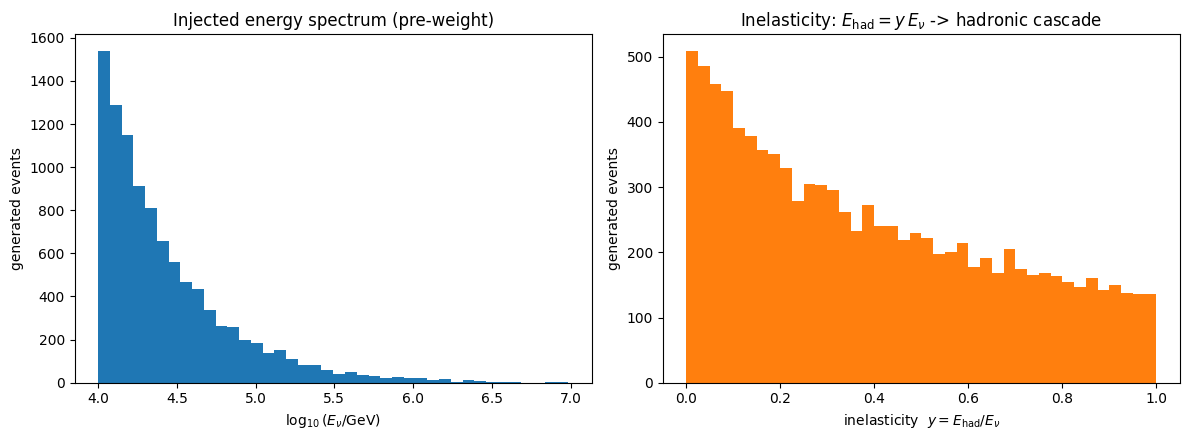

median inelasticity <y> = 0.33


In [8]:
HADRONS = -2000001006     # SIREN particle code for the hadronic system

Enu, y = [], []
for ie in range(len(data)):
    types = np.array(data["secondary_types"][ie][0])
    moms  = np.array(data["secondary_momenta"][ie][0])     # rows: [E, px, py, pz]
    E_nu  = np.array(data["primary_momentum"][ie][0])[0]
    E_had = moms[types == HADRONS][0][0]
    Enu.append(E_nu)
    y.append(E_had / E_nu)
Enu = np.array(Enu); y = np.array(y)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].hist(np.log10(Enu), bins=40, color="C0")
ax[0].set_xlabel(r"$\log_{10}(E_\nu / {\rm GeV})$")
ax[0].set_ylabel("generated events")
ax[0].set_title("Injected energy spectrum (pre-weight)")

ax[1].hist(y, bins=40, range=(0, 1), color="C1")
ax[1].set_xlabel(r"inelasticity  $y = E_{\rm had}/E_\nu$")
ax[1].set_ylabel("generated events")
ax[1].set_title(r"Inelasticity: $E_{\rm had}=y\,E_\nu$ -> hadronic cascade")
plt.tight_layout(); plt.show()

print(f"median inelasticity <y> = {np.median(y):.2f}")


> **★ Discussion.** At these energies the median inelasticity is $\langle y\rangle \approx 0.33$,
> i.e. the **outgoing lepton** keeps most of the energy. Two follow-ups tied to the lectures:
>
> 1. **(Lecture 1, $F_3$)** Neutrinos and antineutrinos have *different* inelasticity distributions
>    because the parity-violating structure function $F_3$ enters with opposite sign — $\bar\nu$
>    events are pushed to lower $y$. Re-run §2 with `primary_type = ...ParticleType.NuMuBar` and
>    overlay the two $y$ histograms. Which one is more sharply peaked at low $y$?
> 2. **(Lecture 2, the mu)** Histogram $(1-y)\,E_\nu$ here, the lepton energy — that's the input to the
>    PROPOSAL study in **notebook 2**.


## 3. Event weights — from generated events to a physical rate

We injected events on an $E^{-2}$ spectrum *just to populate the detector evenly* across energy —
that shape is **not** physical. SIREN's **Weighter** turns each generated event into a physical
rate under a chosen flux $\Phi$:

$$ \frac{dN}{dt} \;=\; \sum_{\text{events}} \underbrace{w_{\rm gen}}_{\text{generation}}\;\times\;\Phi(E)\;\times\;\sigma(E)\;\times\;(\text{geometry}) $$

**Why weighted generation is powerful:** one expensive sample can be reweighted to *any* flux —
change $\gamma$, swap astrophysical for atmospheric — by changing only $\Phi$. No re-simulating the
costly photon propagation (notebook 2).

In SIREN, $\Phi$ lives in the Weighter's `primary_physical_distributions`. We rebuild the Weighter
with different physical fluxes — SIREN's own **`PowerLaw`** for the astrophysical spectrum and a
**`TabulatedFluxDistribution`** built from its own atmospheric table — and call
`weighter.EventWeight(event)` on the **same events**. Because those fluxes are physically
normalized, the weights come out as **absolute rates**, not arbitrary units.


In [ ]:
# SIREN's Weighter turns each generated event into a PHYSICAL rate under a chosen flux:
#     event_weight(event) = w_gen * Phi_phys(E) * sigma(E) * (geometry)
# To reweight the SAME sample to a different flux we just rebuild the Weighter with a new
# `primary_physical_distributions` and re-evaluate -- no manual algebra. And because the
# flux distributions below are PHYSICALLY normalized, event_weight returns an absolute rate.

def event_weights(flux_distribution):
    "Per-event SIREN weight for a given physical energy-flux distribution."
    w = siren.injection.Weighter()
    w.injectors = [injector]
    w.detector_model = detector_model
    w.primary_type = primary_type
    w.primary_interactions = primary_cross_sections
    w.primary_physical_distributions = [flux_distribution,
                                        siren.distributions.IsotropicDirection()]
    return np.array([w.event_weight(ev) for ev in events])

# --- astrophysical flux: SIREN's PowerLaw class, normalized to the IceCube diffuse fit ---
def astro_flux(gamma, phi0=1.68e-18, E0=1e5):
    pl = siren.distributions.PowerLaw(gamma, 1e4, 1e7)   # support = the injection range
    pl.SetNormalizationAtEnergy(phi0*1e4, E0)                # phi0 at E0 = 100 TeV, in m^-2
    return pl

# --- atmospheric flux: SIREN's TabulatedFluxDistribution from its own nu_mu table --------
# We injected nu_mu, so the physical atmospheric background is the atmospheric nu_mu flux
# (the dominant atmospheric flavour). Sky-average the at-detector table over zenith (events
# were injected isotropically) and hand the (energy, dPhi/dE) arrays straight to SIREN. The
# trailing `True` flags the table as a *physical* flux (vs a generation spectrum).
_, _, flux_det_mu = load_atmo_table(f"{MODEL}_osc_numu_numubar")
phi_atmo_mu = flux_det_mu.mean(axis=1)
atmo_flux = siren.distributions.TabulatedFluxDistribution(
    1e4, 1e7, list(E), list(phi_atmo_mu), True)

print("physical fluxes ready: PowerLaw (astro) + TabulatedFluxDistribution (atmo nu_mu).")


### 3a. Reweight the same sample to different fluxes

We build a Weighter for each physical flux and evaluate `EventWeight` on every event, then
histogram the resulting **rate vs energy**: two astrophysical spectral indices (SIREN `PowerLaw`)
and the atmospheric $\nu_\mu$ flux (SIREN `TabulatedFluxDistribution`, from §1's at-detector table).


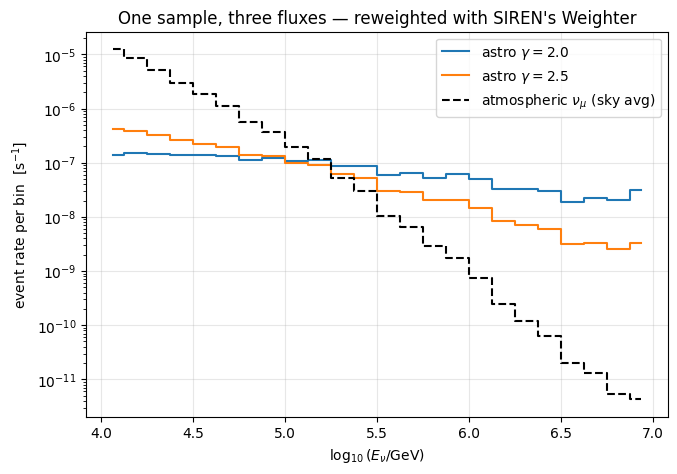

In [10]:
# Reweight the SAME events to three physical fluxes (via SIREN) and histogram the rate vs E.
w_astro_20 = event_weights(astro_flux(2.0))
w_astro_25 = event_weights(astro_flux(2.5))
w_atmo     = event_weights(atmo_flux)

bins = np.linspace(4, 7, 25)                          # log10(E/GeV), 10 TeV - 10 PeV
def rate_curve(weights, label, **kw):
    h, edges = np.histogram(np.log10(Enu), bins=bins, weights=weights)
    plt.step(0.5 * (edges[1:] + edges[:-1]), h, where="mid", label=label, **kw)

plt.figure(figsize=(7.5, 5))
rate_curve(w_astro_20, r"astro $\gamma=2.0$")
rate_curve(w_astro_25, r"astro $\gamma=2.5$")
rate_curve(w_atmo, r"atmospheric $\nu_\mu$ (sky avg)", ls="--", color="k")
plt.yscale("log")
plt.xlabel(r"$\log_{10}(E_\nu / {\rm GeV})$")
plt.ylabel(r"event rate per bin  [s$^{-1}$]")
plt.legend(); plt.grid(alpha=0.3)
plt.title("One sample, three fluxes — reweighted with SIREN's Weighter")
plt.show()


### 3b. A single number: the event rate

Summing a weighted sample gives the **expected event rate**. Because SIREN's physical fluxes are
normalized, these come out as absolute rates (per second) — multiply by a livetime and detection
efficiency for an expected count. The point is the *machinery*: change the flux, get a new rate
instantly, from one generated sample.


In [11]:
print("Integrated event rates (SIREN Weighter, physically-normalized fluxes):")
print(f"  astrophysical  gamma=2.0 : {w_astro_20.sum():.3e}  s^-1")
print(f"  astrophysical  gamma=2.5 : {w_astro_25.sum():.3e}  s^-1")
print(f"  atmospheric    nu_mu    : {w_atmo.sum():.3e}  s^-1")
print()
print("Same generated sample, three fluxes -- only the Weighter's physical flux changed.")
print("Multiply by livetime x detection efficiency for an expected event count.")


Integrated event rates (SIREN Weighter, physically-normalized fluxes):
  astrophysical  gamma=2.0 : 1.955e-06  s^-1
  astrophysical  gamma=2.5 : 2.535e-06  s^-1
  atmospheric    nu_mu    : 3.356e-05  s^-1

Same generated sample, three fluxes -- only the Weighter's physical flux changed.
Multiply by livetime x detection efficiency for an expected event count.


> **★ Discussion.** The dashed atmospheric $\nu_\mu$ curve falls steeply and crosses the
> astrophysical curves; above that energy a detected $\nu_\mu$ is *more likely astrophysical than
> atmospheric*. (i) Read off the crossover energy. (ii) Make the astrophysical spectrum harder
> ($\gamma=2.0$): does the crossover — i.e. the energy threshold for a clean astrophysical $\nu_\mu$ search —
> move up or down? Normalizations here are arbitrary, so it's the **shape and crossover** that carry
> the physics.


## Wrap-up & exercises

You ran the first half of the telescope pipeline **fully live**: SIREN downloaded its own
cross-section and flux data, injected $\nu_\mu$ CC-DIS events into IceCube, and reweighted that one
sample to multiple physical fluxes with its own `Weighter`.

**★ Exercises**

1. **Antineutrinos & $F_3$ (Lecture 1).** This notebook injects $\nu_\mu$ (`NuMu`). Re-run
   §2 with `NuMu` and overlay the inelasticity distributions of $\nu_\mu$ vs $\bar\nu_\mu$.
   Confirm the $\bar\nu$ distribution is pushed to lower $y$.
2. **Hand the mu to notebook 2.** Histogram the outgoing mu energy $(1-y)\,E_\nu$ from §2b — this
   is the initial energy distribution that feeds the PROPOSAL decay-length study in notebook 2.
3. **Astro vs atmo crossover.** Scan $\gamma$ from 2.0 to 3.0 and plot the astrophysical/atmospheric
   crossover energy vs $\gamma$.

**References.** SIREN (Schneider, Kamp, Wen, arXiv:2406.01745); SIREN data on Zenodo (record
20129082); CSMS cross sections (Cooper-Sarkar, Mertsch, Sarkar, JHEP 2011); Formaggio & Zeller,
Rev. Mod. Phys. 84 (2012) for the cross-section + DIS kinematics review.

**Next:** notebook 2 — `2_propagation_and_light.ipynb` — propagates the tau with **PROPOSAL** and
turns the cascade(s) into Cherenkov light and a detector event display with **Prometheus**.
